## Exercise: Multiple Linear Regression

#### In this exercise, we will reinforce our knowledge of the fundamental concepts of multiple linear regression by implementing an MLR model and assessing its accuracy.

### Learning Objectives
#### By the end of this train, you should be able to:
##### - Implement multiple linear regression in Python
##### - Assess model accuracy by interpreting outpurs
##### - Understand what is meant by linearity and multicollinearity of predictors
##### - Understand what is meant by independence, homoscedasticity, and normality of residuals and how we can check these in our model outputs

In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import statsmodels.graphics.correlation as sgc
from statsmodels.graphics.gofplots import qqplot
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import OLSInfluence

In [3]:
# Read the data
environmental_indicators = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/regression_sprint/enviro_indicators.csv', index_col=0)
environmental_indicators.head(10)

,forest_coverage,biodiversity_index,protected_areas,deforestation_rate,carbon_sequestration,soil_erosion,land_degradation,rural_population,population_density
Country,,,,,,,,,
Vietnam,36.217808,6.505159,14.832708,36.583106,53.128459,7.987880,55.020903,35.912142,468.715839
Guinea-Bissau,76.550001,94.888554,23.994363,123.384939,279.836286,13.013811,41.655073,34.639379,351.054600
Bosnia and Herzegovina,61.239576,96.563203,9.932348,115.743745,237.834951,13.037065,26.951490,78.380633,289.329973
Lesotho,51.906094,80.839735,33.076894,111.752369,149.948515,11.179719,27.460479,43.585863,57.616482
Indonesia,20.921305,30.461377,7.609273,46.450326,103.939415,2.715506,46.297784,73.522793,311.353541
Singapore,20.919616,9.767211,39.541043,25.249501,201.926827,16.870747,54.855513,57.868318,495.126387
Saint Lucia,14.065853,68.423303,32.028567,76.130581,474.309367,7.094821,54.354321,67.688678,78.641167
Turkmenistan,70.632330,44.015249,11.955049,73.358093,195.441319,4.543852,48.993777,50.158226,263.981530
Kenya,52.078051,12.203823,5.193274,36.843972,283.455780,1.774728,42.101582,54.614233,439.912805


## Exercises

#### Exercise 1: Print the first few rows of the dataset, the summary statistic, and check for missing values. Doing this provides an overview of the structure of the data and highlights whether there are any issues with missing data

In [4]:
environmental_indicators.describe()

,forest_coverage,biodiversity_index,protected_areas,deforestation_rate,carbon_sequestration,soil_erosion,land_degradation,rural_population,population_density
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,40.484972,49.873676,22.542576,69.063387,255.649653,9.874722,35.263996,53.223641,299.594850
std,19.529573,32.201278,10.338851,30.100259,132.047729,5.464372,14.555348,18.552335,129.851023
min,11.440915,3.438852,5.193274,18.113759,53.128459,1.315169,10.253079,20.927397,27.611714
25%,22.810674,24.308070,14.113293,46.131162,158.644367,5.113528,21.700207,37.461786,227.116183
50%,38.226980,46.766470,24.319532,70.838794,225.734136,10.896565,40.988263,51.783151,319.917934
75%,52.603530,81.348239,31.716570,90.632026,355.935380,13.623203,45.781167,71.766124,402.520220
max,77.893690,96.958463,39.541043,128.118420,493.542704,18.797870,55.020903,78.380633,495.126387


In [5]:
environmental_indicators.shape

(32, 9)

In [6]:
environmental_indicators.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Vietnam to Liechtenstein
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   forest_coverage       32 non-null     float64
 1   biodiversity_index    32 non-null     float64
 2   protected_areas       32 non-null     float64
 3   deforestation_rate    32 non-null     float64
 4   carbon_sequestration  32 non-null     float64
 5   soil_erosion          32 non-null     float64
 6   land_degradation      32 non-null     float64
 7   rural_population      32 non-null     float64
 8   population_density    32 non-null     float64
dtypes: float64(9)
memory usage: 2.5+ KB


#### Exercise 2: Create a correlation matrix using the columns in the data. We do this to see whether there are potentially strong relationships between the independent variables and the dependant variable, but it can also be used to investigate potential multicollinearity between the independent variables.

In [7]:
corr_matrix = environmental_indicators.corr()
print(corr_matrix.round(2))

                      forest_coverage  biodiversity_index  protected_areas  \
forest_coverage                  1.00                0.27             0.11   
biodiversity_index               0.27                1.00            -0.07   
protected_areas                  0.11               -0.07             1.00   
deforestation_rate               0.56                0.92             0.12   
carbon_sequestration             0.05                0.01             0.15   
soil_erosion                    -0.11               -0.06             0.32   
land_degradation                 0.15               -0.14            -0.11   
rural_population                 0.02                0.04             0.17   
population_density               0.03               -0.14            -0.00   

                      deforestation_rate  carbon_sequestration  soil_erosion  \
forest_coverage                     0.56                  0.05         -0.11   
biodiversity_index                  0.92                  0

In [8]:
from statsmodels.graphics.correlation import plot_corr

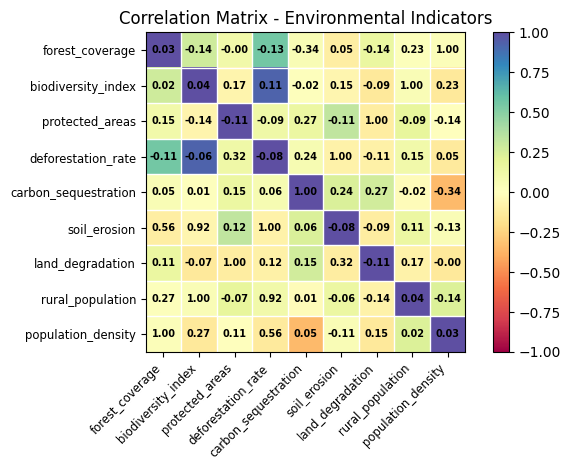

In [17]:
n = len(corr_matrix)

plot_corr(
    corr_matrix,
    xnames=corr_matrix.columns.tolist(),
    title='Correlation Matrix - Environmental Indicators',
    normcolor=True,
    cmap='Spectral'
)

ax = plt.gca()

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

cell_width = (x_max - x_min) / n
cell_height = (y_max - y_min) / n

for i in range(n):
    for j in range(n):
        x_center = x_min + (j + 0.5) * cell_width
        y_center = y_min + (i + 0.5) * cell_height
        
        ax.text(
            x_center,
            y_center,
            f'{corr_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center',
            fontsize=7,
            fontweight='bold',
            color='black'
        )

plt.tight_layout()
plt.show()

#### Exercise 3: Knowing what we know about the relationships between the variables, it's time to build our regression model. To get started, include all the numeric variables in the model. Remember that ***biodiversity_index*** is the dependent variable

#### Print the summary of the fitted model

In [21]:
# Specifying the variables of interest
independent_cols = ['forest_coverage', 'protected_areas', 'deforestation_rate', 'carbon_sequestration', 'soil_erosion', 'land_degradation', 'rural_population', 'population_density']

dependent_var = 'biodiversity_index'

In [27]:
import statsmodels.api as sm

In [40]:
X = environmental_indicators[independent_cols]
y = environmental_indicators[dependent_var]

In [34]:
X = sm.add_constant(X)

In [35]:
model = sm.OLS(y, X).fit()

In [36]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     biodiversity_index   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     85.25
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           2.99e-15
Time:                        13:00:53   Log-Likelihood:                -101.24
No. Observations:                  32   AIC:                             220.5
Df Residuals:                      23   BIC:                             233.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.2536 

#### Exercise 4: The output from this model seems somewhat strange, with a comment warning of probable multicolinearity. Furthermore, some of the coefficient p-values are rather high (larger than expected). It may be worthwhile to consider which variables appear to be associated with the dependent variable, maintaining those, and possibly removing a few additional factors where there is potential for multicolinearity.

#### Create another version of the model with fewer independent variables and see if the warning can be silenced

In [54]:
independent_cols_v2 = ['forest_coverage', 'protected_areas', 'deforestation_rate', 'soil_erosion', 'rural_population']

In [55]:
X_v2 = environmental_indicators[independent_cols_v2]
y_v2 = environmental_indicators[dependent_var]

In [56]:
X_v2 = sm.add_constant(X_v2)

In [57]:
model_v2 = sm.OLS(y_v2, X_v2).fit()

In [58]:
print(model_v2.summary())

                            OLS Regression Results                            
Dep. Variable:     biodiversity_index   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     146.1
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           3.59e-18
Time:                        13:29:56   Log-Likelihood:                -102.07
No. Observations:                  32   AIC:                             216.1
Df Residuals:                      26   BIC:                             224.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.4728      4

#### Exercise 5: Evaluate the accuracy and reliability of the multiple linear regression model by conducting various diagnostic tests. Check for linearity by visually inspecting scatter plots between each independent variable and the biodiversity index. This will help in understanding whether the relationship between the independent variables and the biodiversity index is linear.

#### What can we conclude from the charts? Are there any linear relationships visible?

In [63]:
import math

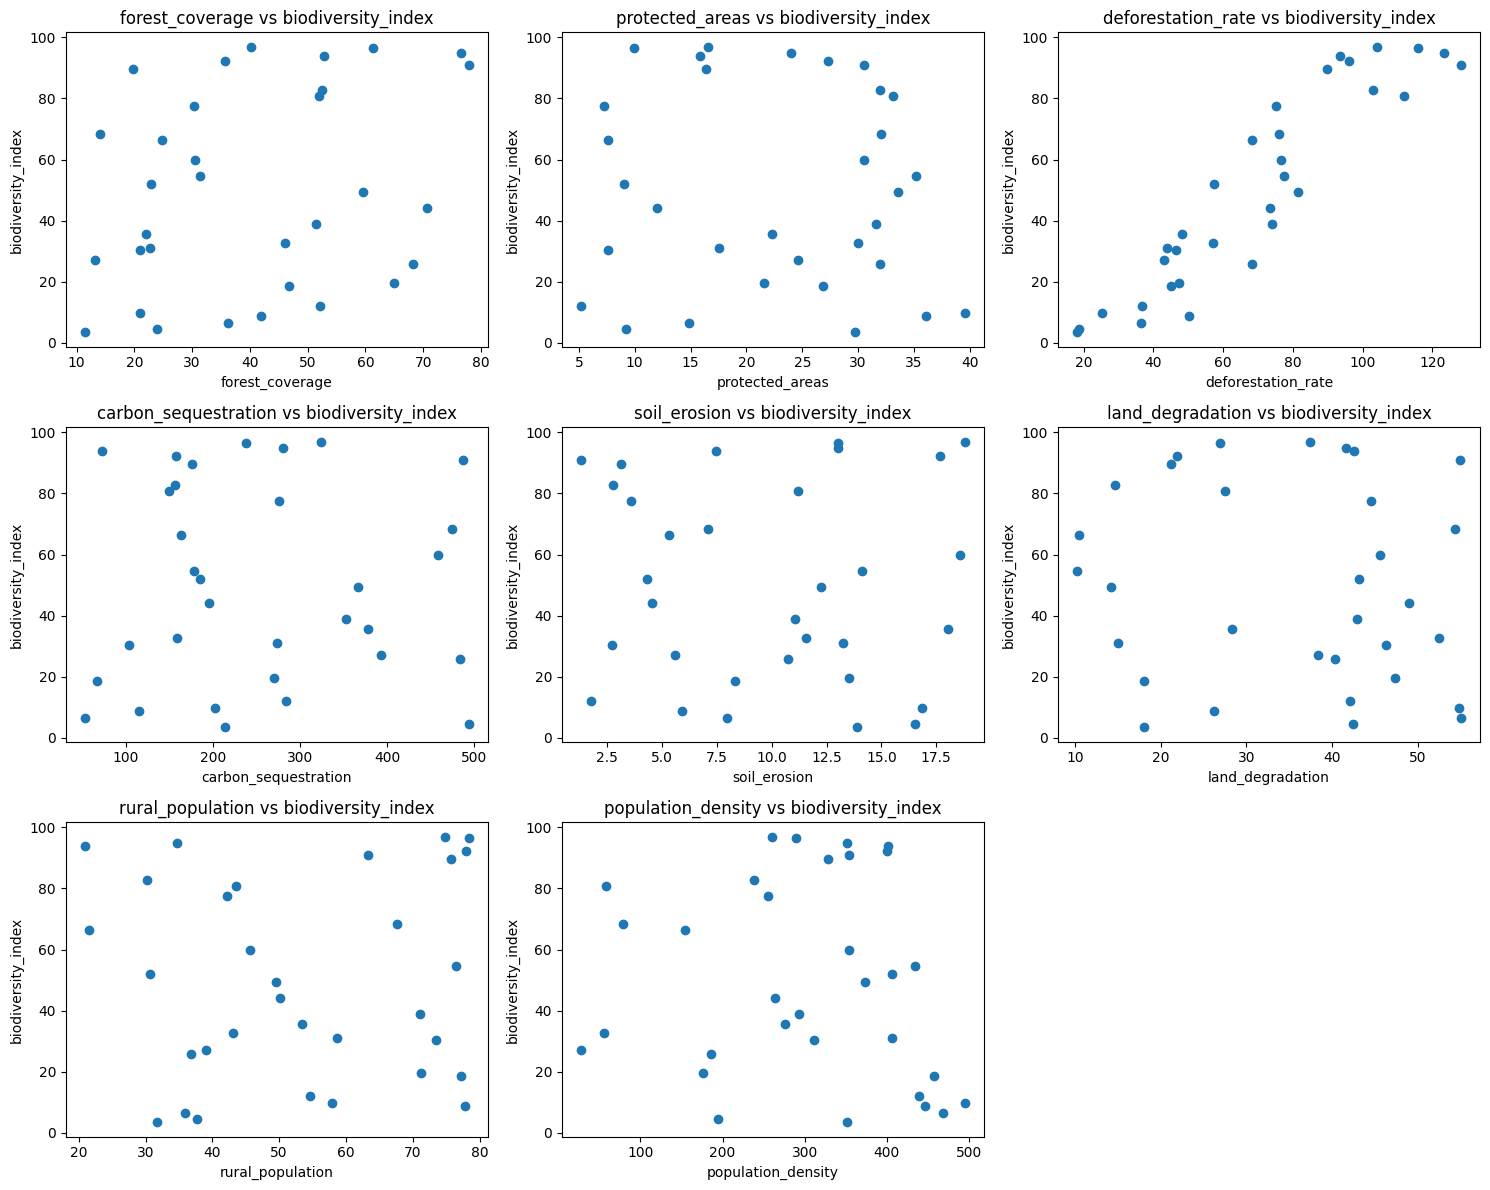

In [74]:
num_plots = len(independent_cols)

cols = math.ceil(math.sqrt(num_plots))
rows = math.ceil(num_plots / cols)

fig, axs = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))

if num_plots == 1:
    axs = [axs]
else:
    axs = axs.flatten()

for i, predictor in enumerate(independent_cols):
    axs[i].scatter(environmental_indicators[predictor], environmental_indicators[dependent_var])
    
    axs[i].set_title(f'{predictor} vs {dependent_var}')
    axs[i].set_xlabel(predictor)
    axs[i].set_ylabel(dependent_var)
    
for ax in axs[num_plots:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

#### Exercise 6: Visualise the relationship between predictor variables and model residuals to assess the independence of residuals using scatter plots. Do you see any obvious dependence of residuals? How would we know?

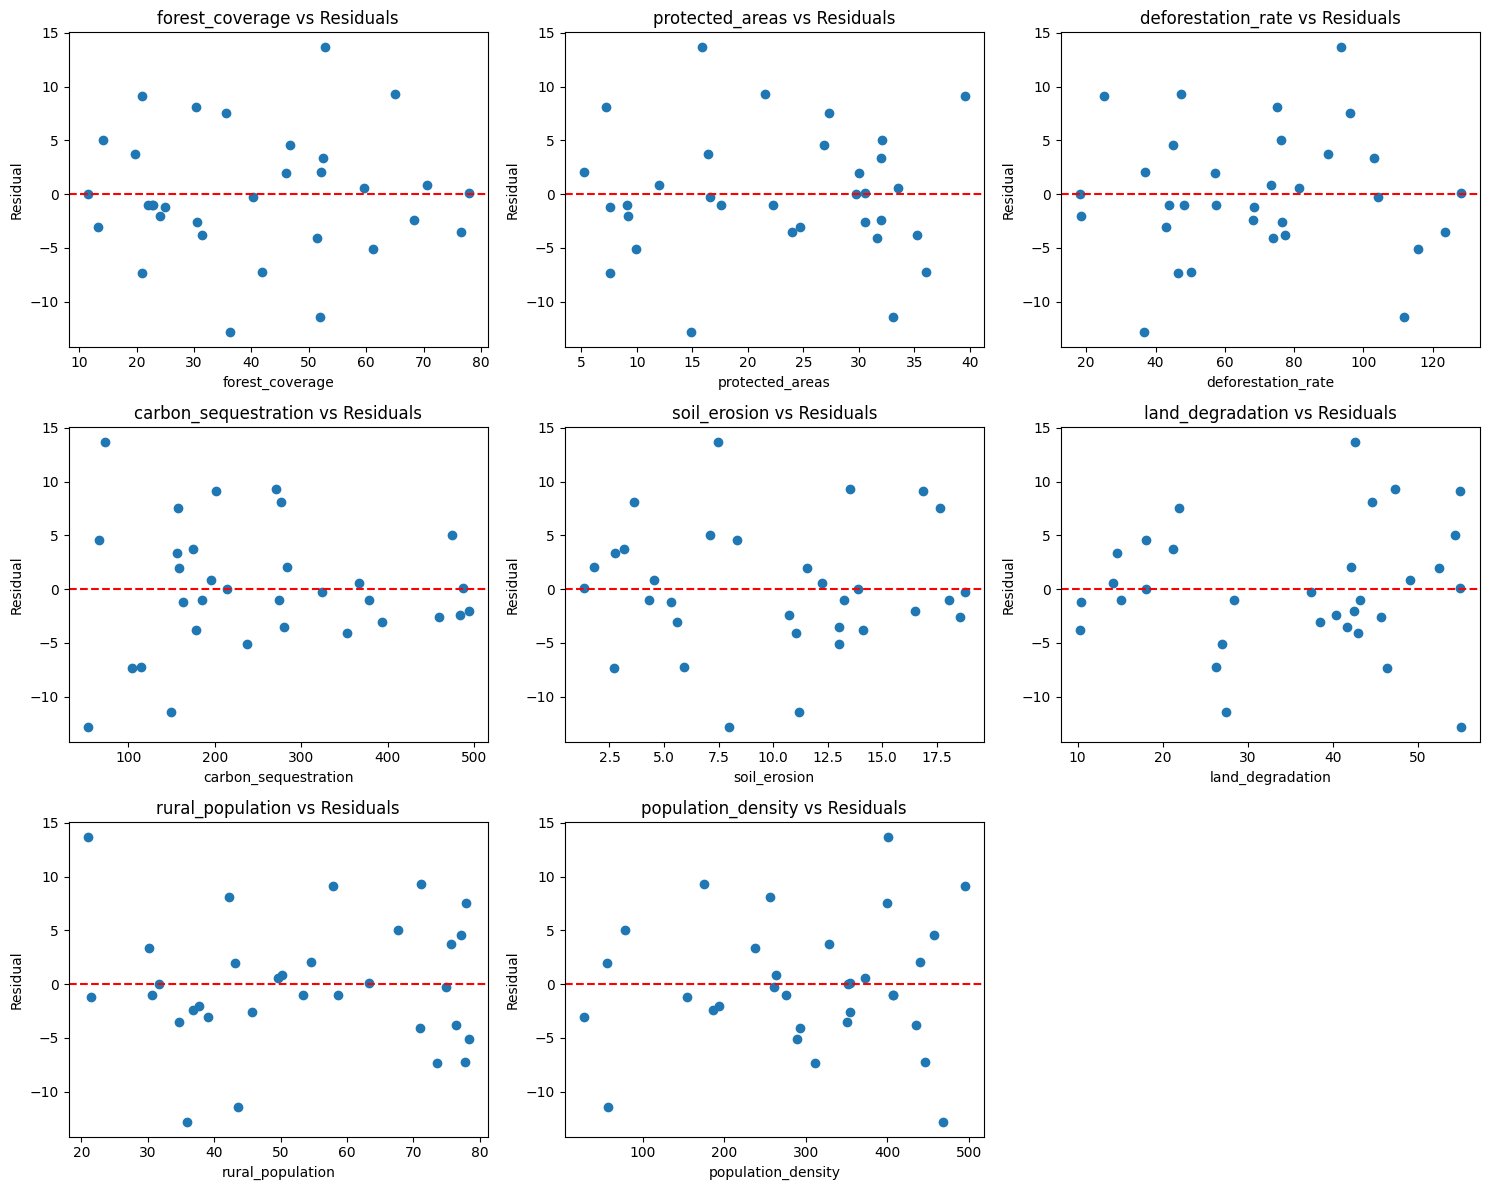

In [78]:
residuals = model.resid

num_plots = len(independent_cols)

cols = math.ceil(math.sqrt(num_plots))
rows = math.ceil(num_plots / cols)

fig, axs = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))

axs = axs.flatten()

if num_plots == 1:
    axs = [axs]
else:
    axs = axs.flatten()

for i, predictor in enumerate(independent_cols):
    axs[i].scatter(environmental_indicators[predictor], residuals)
    
    # Horizontal reference line at zero
    axs[i].axhline(0, color='red', linestyle='--')
    
    axs[i].set_title(f'{predictor} vs Residuals')
    axs[i].set_xlabel(predictor)
    axs[i].set_ylabel('Residual')
    
for ax in axs[num_plots:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

#### Exercise 7: Check for homoscedasticity by conducting a ***Breush-Pagan*** test on our model. Interpret the results to determine whether homoscedasticity could possibly be satisfied for our regression model

In [79]:
from statsmodels.stats.diagnostic import het_breuschpagan

In [80]:
# Perform the Breusch-Pagan test
lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(
        model.resid, model.model.exog
        )

In [81]:
print(f'LM Statistic : {lm_stat:.4f}')
print(f'LM p-value : {lm_pvalue:.4f}')
print(f'F Statistic : {f_stat:.4f}')
print(f'F p-value: {f_pvalue:.4f}')

if lm_pvalue > 0.05:
    print('\nConclusion:')
    print('The model satisfies the homoskedasticity assumption.')
else:
    print('\nConclusion:')
    print('The model violates the homoscedasticity assumption.')

LM Statistic : 9.3375
LM p-value : 0.1555
F Statistic : 1.7168
F p-value: 0.1585

Conclusion:
The model satisfies the homoskedasticity assumption.


#### Exercise 8: Check for the normality of residuals by creating a Q-Q plot of the normalised residuals to visually assess their normality

In [82]:
normalised_residuals = model.get_influence().resid_studentized_internal

In [83]:
from scipy import stats

((array([-2.02511189, -1.62590278, -1.38593914, -1.20666642, -1.05953591,
         -0.93235918, -0.81872017, -0.71478609, -0.6180591 , -0.52680137,
         -0.43973827, -0.35589149, -0.27447843, -0.19484777, -0.11643566,
         -0.03873405,  0.03873405,  0.11643566,  0.19484777,  0.27447843,
          0.35589149,  0.43973827,  0.52680137,  0.6180591 ,  0.71478609,
          0.81872017,  0.93235918,  1.05953591,  1.20666642,  1.38593914,
          1.62590278,  2.02511189]),
  array([-2.16673229, -1.94269184, -1.29582839, -1.29132254, -0.925075  ,
         -0.65891682, -0.63445718, -0.61956337, -0.5239523 , -0.45061784,
         -0.43096446, -0.38270612, -0.21277193, -0.17676238, -0.17006965,
         -0.15772921, -0.05177027, -0.00313934,  0.02856691,  0.09881329,
          0.14612085,  0.31440684,  0.37477471,  0.59126768,  0.66976896,
          0.79065407,  0.94556114,  1.31097877,  1.34360029,  1.60614744,
          1.62717478,  2.41281062])),
 (1.0422602417031153, 0.0051742317418

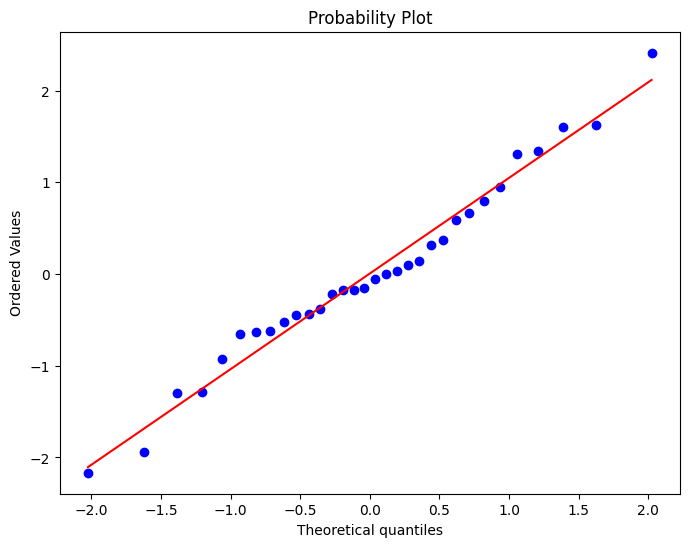

In [84]:
plt.figure(figsize=(8,6))

stats.probplot(
    normalised_residuals,
    dist='norm',
    plot=plt
)

#### Exercise 9: To ensure the accuracy of our regression model, it's crucial to check for outliers that might significantly affect the model's coefficients and predictions. Use Cook's distance to visually inspect a plot of residuals vs. fitted values by identifying potential outliers.

#### Interpret the results

Text(0.5, 1.0, "Residuals vs Fitted values\nCook's distance Outliers labelled")

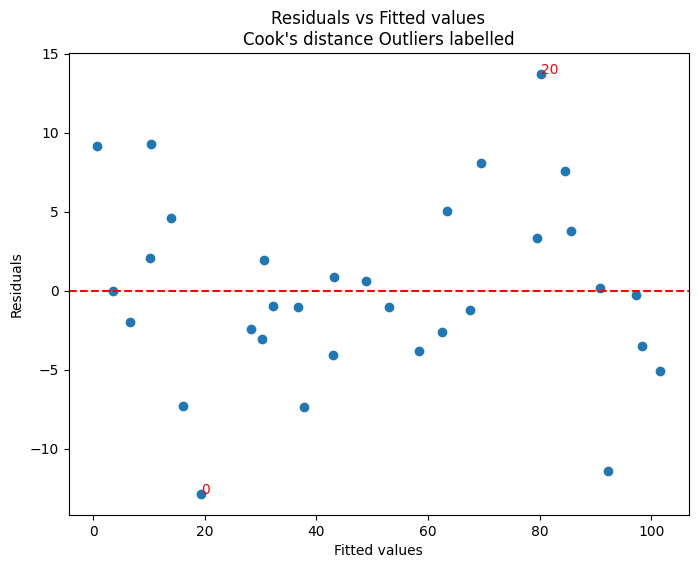

In [85]:
# Obtain diagnostics
fitted_values = model.fittedvalues
diagnostic_residuals = model.resid

influence = model.get_influence()
cooks_distance = influence.cooks_distance[0]

# Rule of thumb threshold
threshold = 4 / len(environmental_indicators)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(fitted_values, diagnostic_residuals)
plt.axhline(0, color='red', linestyle='--')

for i in range(len(environmental_indicators)):
    if cooks_distance[i] > threshold:
        plt.annotate(
            i,
            (fitted_values[i], residuals[i]),
            color='red'
        )

plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values\nCook\'s distance Outliers labelled')

In [86]:
independent_cols = ['forest_coverage',  'protected_areas',
       'deforestation_rate', 'carbon_sequestration', 'soil_erosion',
       'land_degradation', 'rural_population', 'population_density']

dependent_var = 'biodiversity_index'

# Generating the regression string
formula_str = dependent_var+ ' ~ ' + ' + '.join(independent_cols)
formula_str
# Construct and fit the model
model = smf.ols(formula=formula_str, data=environmental_indicators)
fitted = model.fit()

# Print the summary of the fitted model
print(fitted.summary())

                            OLS Regression Results                            
Dep. Variable:     biodiversity_index   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     85.25
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           2.99e-15
Time:                        12:31:20   Log-Likelihood:                -101.24
No. Observations:                  32   AIC:                             220.5
Df Residuals:                      23   BIC:                             233.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.2536 

In [87]:
# dropped population density, land_degradation, carbon sequestration
independent_cols_reduced = ['forest_coverage',  'protected_areas',
       'deforestation_rate', 'soil_erosion',
        'rural_population']

dependent_var = 'biodiversity_index'

# Generating the regression string
formula_str = dependent_var+ ' ~ ' + ' + '.join(independent_cols_reduced)
formula_str
# Construct and fit the model
model = smf.ols(formula=formula_str, data=environmental_indicators)
fitted = model.fit()

# Print the summary of the fitted model
print(fitted.summary())

                            OLS Regression Results                            
Dep. Variable:     biodiversity_index   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     146.1
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           3.59e-18
Time:                        12:38:41   Log-Likelihood:                -102.07
No. Observations:                  32   AIC:                             216.1
Df Residuals:                      26   BIC:                             224.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.4728      4

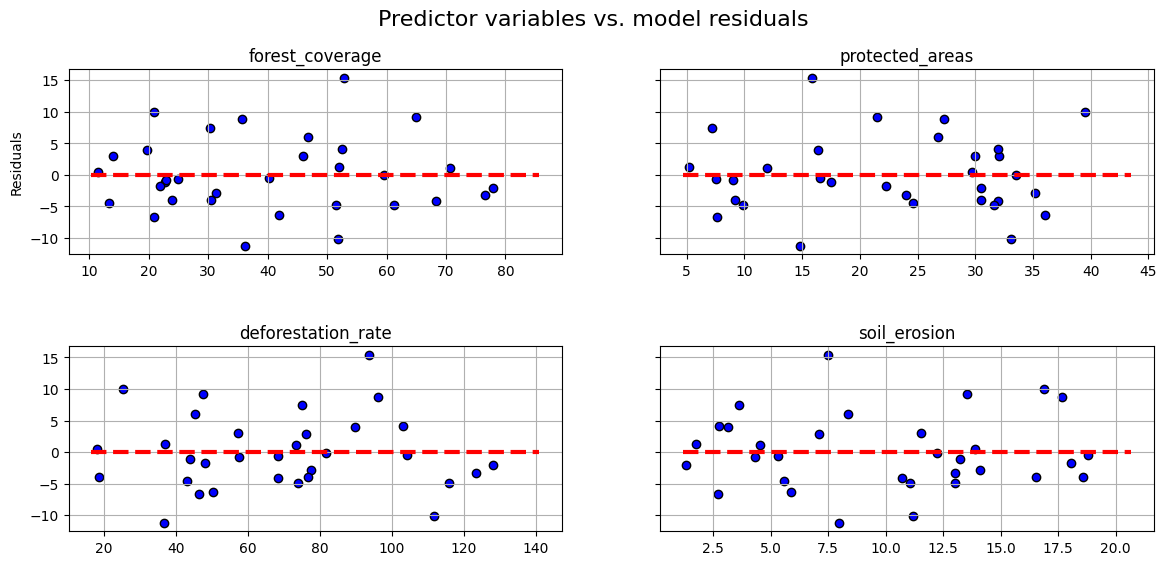

In [88]:
reduced_matrix = environmental_indicators[independent_cols_reduced]

# Plotting predictor variables vs. model residuals
fig, axs = plt.subplots(2, 2, figsize=(14, 6), sharey=True)  # Adjusted to 2 rows and 4 columns
fig.subplots_adjust(hspace=0.5, wspace=0.2)
fig.suptitle('Predictor variables vs. model residuals', fontsize=16)
axs = axs.ravel()

for index, column in enumerate(reduced_matrix):
    if index < len(axs):  # Ensure we don't exceed the number of subplots
        axs[index].set_title("{}".format(column), fontsize=12)
        axs[index].scatter(x=environmental_indicators[column], y=fitted.resid, color='blue', edgecolor='k')
        axs[index].grid(True)
        xmin = min(environmental_indicators[column])
        xmax = max(environmental_indicators[column])
        axs[index].hlines(y=0, xmin=xmin*0.9, xmax=xmax*1.1, color='red', linestyle='--', lw=3)
        if index == 0 or index == 4:
            axs[index].set_ylabel('Residuals')

In [89]:
# 1. Calculate residuals
residuals = fitted.resid

# 2. Perform Breusch-Pagan Test
bp_test_result = sms.het_breuschpagan(residuals, fitted.model.exog)
print("Breusch-Pagan Test Results:")
print("LM Statistic:", bp_test_result[0])
print("LM-Test p-value:", bp_test_result[1])
print("F-Statistic:", bp_test_result[2])
print("F-Test p-value:", bp_test_result[3])

Breusch-Pagan Test Results:
LM Statistic: 1.16425313233011
LM-Test p-value: 0.9482604748380214
F-Statistic: 0.1963343490299595
F-Test p-value: 0.9611146316365254


<Figure size 800x500 with 0 Axes>

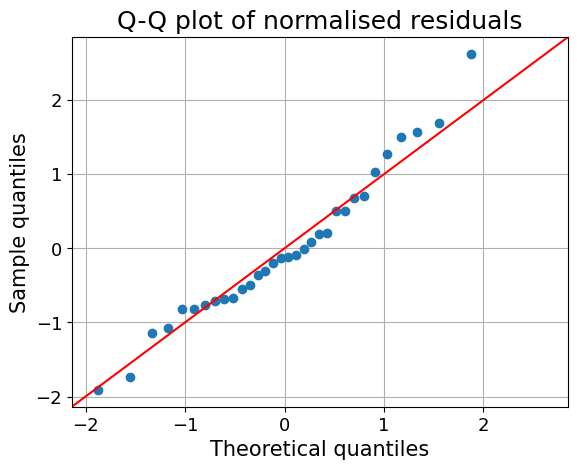

In [92]:
# Q-Q plot of normalised residuals
plt.figure(figsize=(8, 5))
fig = qqplot(fitted.resid_pearson, line='45', fit=True)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("Theoretical quantiles", fontsize=15)
plt.ylabel("Sample quantiles", fontsize=15)
plt.title("Q-Q plot of normalised residuals", fontsize=18)
plt.grid(True)
plt.show()

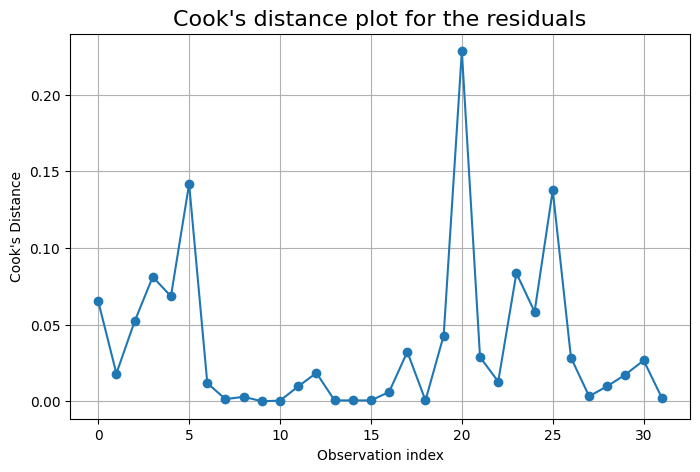

In [93]:
# Calculate Cook's distance
influence = OLSInfluence(fitted)
(c, p) = influence.cooks_distance

# Plot Cook's distance
plt.figure(figsize=(8, 5))
plt.title("Cook's distance plot for the residuals", fontsize=16)
plt.plot(np.arange(len(c)), c, marker='o', linestyle='-')
plt.xlabel('Observation index')
plt.ylabel("Cook's Distance")
plt.grid(True)
plt.show()

In [94]:
c

Country
Vietnam                     0.065267
Guinea-Bissau               0.018081
Bosnia and Herzegovina      0.052027
Lesotho                     0.081131
Indonesia                   0.068473
Singapore                   0.141831
Saint Lucia                 0.011773
Turkmenistan                0.001383
Kenya                       0.002861
United States               0.000003
Cabo Verde                  0.000379
Guinea-Bissau               0.009653
Dominica                    0.018466
Liberia                     0.000551
Venezuela                   0.000527
Saint Lucia                 0.000533
Trinidad and Tobago         0.006044
Kazakhstan                  0.032196
Congo                       0.000534
Malawi                      0.042833
Central African Republic    0.228368
Malaysia                    0.028828
Botswana                    0.012787
Austria                     0.083554
Guinea-Bissau               0.058333
Malawi                      0.137629
Chad                        0.